# *Python-Based Computing Platforms for Capstone Projects: PyTorch, GurobiPy, and PyEPO*

 Welcome to this tutorial! This notebook will introduce you to three powerful Python libraries that can be highly useful for your capstone projects:

 - **PyTorch**: A deep learning library.
 - **GurobiPy**: A mathematical optimization library.
 - **PyEPO**: A predictive optimization library that integrates machine learning with optimization.

**Objective**: By the end of this tutorial, you'll have basic hands-on experience with each library and understand how to apply them to real-world problems.


## 1. **Section 1: PyTorch - Deep Learning Library**
PyTorch is a popular deep-learning framework known for its flexibility and ease of use. It's often used in machine learning applications such as image classification, NLP, and more. In this section, we’ll go through key concepts like tensors, autograd, and create a simple neural network.
[PyTorch Documentation](https://pytorch.org/tutorials/beginner/basics/intro.html)

The [PyTorch installation page](https://pytorch.org/get-started/locally/) provides specific installation instructions based on your system setup.

In [1]:
# !pip install torch torchvision torchaudio

### 1.1 Tensor Introduction
Tensors are the primary data structure in PyTorch, similar to arrays in NumPy. Let's start by creating some tensors and exploring basic operations.

In [2]:
import torch
import numpy as np

In [3]:
# Initializing data
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)
print(f'Printing x_data tensor created from list : {x_data}')

# From ndarray to tensor
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(f'Printing x_np tensor created from ndarray : {x_data}')


Printing x_data tensor created from list : tensor([[1, 2],
        [3, 4]])
Printing x_np tensor created from ndarray : tensor([[1, 2],
        [3, 4]])


In [4]:
# Set a random seed for both CPU and GPU
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    torch.cuda.manual_seed_all(0)  # if using multi-GPU.

In [5]:
# Creating diiferent tensors
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, 0.6341]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [6]:
# Creating a tensor without specifying requires_grad
x = torch.tensor([1.0, 2.0, 3.0])
print(x.requires_grad)  # This will print False

# Creating a tensor with requires_grad=True
y = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
print(y.requires_grad)  # This will print True

False
True


If you’re using Colab, allocate a GPU by going to Runtime > Change runtime type > GPU.

In [7]:
tensor = torch.tensor([1.0, 2.0, 3.0])
tensor.device

device(type='cpu')

In [8]:
# We move our tensor to the GPU if available
if torch.cuda.is_available():
    tensor = tensor.to("cuda")
tensor.device

device(type='cuda', index=0)

### 1.2 Dataset and DataLoader

PyTorch provides two data primitives: torch.utils.data.DataLoader and torch.utils.data.Dataset that allow you to use pre-loaded datasets as well as your own data.
  - **Dataset** stores the samples and their corresponding labels.
  - **DataLoader** wraps an iterable around the Dataset to enable easy access to the samples. This allows us to decouple the training process from dataset code and hence improve the readability of the code. Here we introduce how we can use these tools.

Dataset stores all your data and DataLoader can be used to iterate through the data, manage batches, transform the data, and much more.



In [9]:
# You can link your google drive to read a dataset file using the following
from google.colab import drive
import os

drive.mount('/content/drive')
work_pth = '/content/drive/MyDrive/Wyame/' # customize this line to your working directory
os.chdir(work_pth)

Mounted at /content/drive


In [10]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# We use Ames data which we used in 142A/242A.
ames_data = pd.read_csv('../data/raw/Ames_cleaned.csv')
# We are only going to use subset of the features to train the model
ames = ames_data[['LogSalePrice','MSSubClass', 'OverallQual','YearsSince1950Built','GrLivArea','TotRmsAbvGrd','FullBath','SaleCondition','YrSold']]

# Change remaining categorical variable types into 'category' type
still_categorical = ames.columns[ames.dtypes == 'object']
ames[still_categorical] = ames[still_categorical].astype('category')

# Dummy Encoding
ames_encoded = pd.get_dummies(ames.select_dtypes(include=['category'])).astype('int')
ames_encoded = pd.concat([ames.select_dtypes(exclude=['category']),ames_encoded],axis=1)
ames_encoded

ames_encoded.head(5)

<ipython-input-10-610834777775>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ames[still_categorical] = ames[still_categorical].astype('category')


,LogSalePrice,MSSubClass,OverallQual,YearsSince1950Built,GrLivArea,TotRmsAbvGrd,FullBath,YrSold,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,12.278393,20,6,10,1656.0,7,1,2010,0,0,0,0,1,0
1,11.561716,20,5,11,896.0,5,1,2010,0,0,0,0,1,0
2,12.055250,20,6,8,1329.0,6,1,2010,0,0,0,0,1,0
3,12.404924,20,7,18,2110.0,8,2,2010,0,0,0,0,1,0
4,12.154253,60,5,47,1629.0,6,2,2010,0,0,0,0,1,0


In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scale our data: Scaling is actually important when using SGD based optimizer.

# Select columns with dtype float
cols = ames_encoded.select_dtypes(include=['float','int']).columns

# Exclude 'LogSalePrice' and 'YrSold' from the list
cols = [item for item in cols if item != "LogSalePrice" and item !="YrSold"]

# Standardization
scaler = StandardScaler()
ames_encoded[cols] = scaler.fit_transform(ames_encoded[cols])

ames_encoded.head()
# Devide the data into training and the test set
ames_train_encoded = ames_encoded.loc[ames_encoded['YrSold'].isin([2006, 2007, 2008])]
ames_test_encoded = ames_encoded.loc[ames_encoded['YrSold'].isin([2009, 2010])]

ames_train_encoded.drop(columns = ['YrSold'], inplace=True)
ames_test_encoded.drop(columns = ['YrSold'], inplace=True)
ames_encoded.drop(columns = ['YrSold'], inplace=True)

print(ames_encoded.shape, ames_train_encoded.shape, ames_test_encoded.shape)

(2924, 13) (1935, 13) (989, 13)


<ipython-input-11-ef028483fa1a>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ames_train_encoded.drop(columns = ['YrSold'], inplace=True)
<ipython-input-11-ef028483fa1a>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ames_test_encoded.drop(columns = ['YrSold'], inplace=True)


PyTorch domain libraries provide a number of pre-loaded datasets. [Pytorch dataset Link](https://pytorch.org/vision/main/datasets.html)

A custom Dataset class must implement three functions: __init__, __len__, and __getitem__.


In [12]:
# Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Assuming the DataFrame has two columns: features and target
        x = torch.tensor(self.data.iloc[idx, 1:].values, dtype=torch.float32)
        y = torch.tensor(self.data.iloc[idx,0], dtype=torch.float32).unsqueeze(0)
        return x, y


In [13]:
# Creating ptorch dataset and dataloader
train_dataset = CustomDataset(ames_train_encoded)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# test_dataset = CustomDataset(ames_test_encoded)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

x_test = torch.tensor(ames_test_encoded.iloc[:, 1:].values, dtype=torch.float32)
y_test = torch.tensor(ames_test_encoded.iloc[:,0], dtype=torch.float32).unsqueeze(0).T

### 1.3 Building Model using Pytorch
In this section, we will build a simple neural network model using PyTorch’s nn.Module class. PyTorch’s neural networks are defined as subclasses of nn.Module, which gives us an easy way to define layers and forward passes.

In [14]:
num_features = ames_train_encoded.shape[1] - 1
num_hidden_units = 20  # You can choose the number of units in the hidden layer
num_items = 1  # we are predicting LogSalePrice


In [15]:
from torch import nn

class OneHiddenLayer(nn.Module):
    def __init__(self):
        super(OneHiddenLayer, self).__init__()
        # Define the hidden layer
        self.hidden = nn.Linear(num_features, num_hidden_units)
        # Define the ReLU activation function
        self.relu = nn.ReLU() # We can use othr activation function depending on the application
        # Define the output layer
        self.output = nn.Linear(num_hidden_units, num_items)

    def forward(self, x):
        # Pass the input through the hidden layer, then through ReLU, and finally through the output layer
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x


In [16]:
import time

# Define a function for training.
def train_model(model, loss_func, num_epochs, optim, train_loader, x_test, y_test ):

  train_loss_log = []
  test_loss_log = []

  # Move model to GPU if CUDA is available
  if torch.cuda.is_available():
      model = model.cuda()
      x_test = x_test.cuda()
      y_test = y_test.cuda()
  tic = time.time()
  for epoch in range(1,num_epochs+1):
    for i, data in enumerate(train_loader):
      x, y = data
      # check if cuda is available
      if torch.cuda.is_available():
        x , y = x.cuda(), y.cuda()
      # get predicted y value from our current model
      pred_y = model(x)
      # calculate the loss
      loss = loss_func(pred_y,y)
      # Zero the gradient of the optimizer
      optimizer.zero_grad() # fill in here
      # Backward pass: Compute gradient of the loss with respect to model parameters
      loss.backward()
      # update weights
      optimizer.step()
    # change the model to evaluation mode to calculate the test loss; We will come back to this later after learning Dropout and Batch Normalization
    train_loss_log.append(loss.item())
    model.eval()
    test_pred_y = model(x_test)
    test_loss = loss_func(test_pred_y,y_test)
    test_loss_log.append(test_loss.item())
    # change back to training mode.
    model.train()
    print("Epoch {:2},  Training Loss: {:9.4f},  Test Loss: {:7.4f}".format(epoch, loss.item(), test_loss.item()))
  toc = time.time()
  print("Elapsed Time : {:7.2f}".format(toc-tic))
  return train_loss_log, test_loss_log

In order to train the network, we need to define:
- Optimizer
- Loss Function

PyTorch provides built-in optimizers and loss functions that can be used to train the model. However, just like with custom datasets, you can also create [custom loss functions](https://www.geeksforgeeks.org/how-to-create-a-custom-loss-function-in-pytorch/) in PyTorch to better suit the specific requirements of your task.

In [17]:
one_hidden_layer_relu = OneHiddenLayer()
learning_rate = 1e-2
optimizer = torch.optim.Adam(one_hidden_layer_relu.parameters(), lr=learning_rate)
# optimizer = torch.optim.SGD(one_hidden_layer_relu.parameters(), lr= learning_rate)

loss_func = nn.MSELoss()  # Mean squared error loss
num_epochs = 50
train_loss_log, test_loss_log = train_model(one_hidden_layer_relu, loss_func, num_epochs, optimizer, train_loader, x_test, y_test)

Epoch  1,  Training Loss:   12.4678,  Test Loss: 12.2449
Epoch  2,  Training Loss:    2.5958,  Test Loss:  1.5280
Epoch  3,  Training Loss:    0.1910,  Test Loss:  0.6267
Epoch  4,  Training Loss:    0.4034,  Test Loss:  0.3838
Epoch  5,  Training Loss:    0.0871,  Test Loss:  0.2730
Epoch  6,  Training Loss:    0.0463,  Test Loss:  0.2042
Epoch  7,  Training Loss:    0.0849,  Test Loss:  0.1498
Epoch  8,  Training Loss:    0.0840,  Test Loss:  0.1288
Epoch  9,  Training Loss:    0.0477,  Test Loss:  0.1094
Epoch 10,  Training Loss:    0.0546,  Test Loss:  0.1001
Epoch 11,  Training Loss:    0.0390,  Test Loss:  0.0942
Epoch 12,  Training Loss:    0.0648,  Test Loss:  0.0791
Epoch 13,  Training Loss:    0.0705,  Test Loss:  0.0726
Epoch 14,  Training Loss:    0.1128,  Test Loss:  0.0680
Epoch 15,  Training Loss:    0.2428,  Test Loss:  0.0647
Epoch 16,  Training Loss:    0.0191,  Test Loss:  0.0631
Epoch 17,  Training Loss:    0.0267,  Test Loss:  0.0618
Epoch 18,  Training Loss:    0.

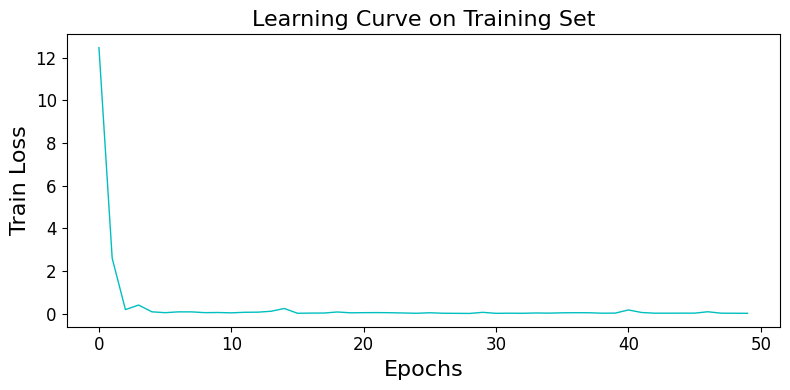

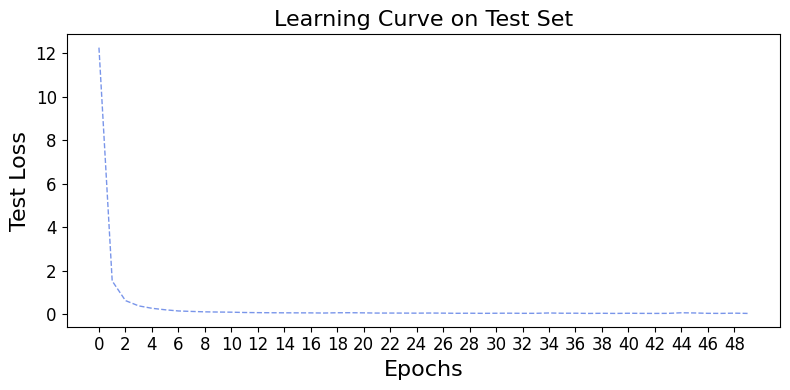

In [18]:
from matplotlib import pyplot as plt

def visLearningCurve(train_loss_log, test_loss_log):
    # create figure and subplot for training loss
    fig1, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(train_loss_log, color="c", lw=1)
    ax1.tick_params(axis="both", which="major", labelsize=12)
    ax1.set_xlabel("Epochs", fontsize=16)
    ax1.set_ylabel("Train Loss", fontsize=16)
    ax1.set_title("Learning Curve on Training Set", fontsize=16)
    fig1.tight_layout()
    fig1.savefig("train_loss_curve.png")

    # create figure and subplot for test loss
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.plot(test_loss_log, color="royalblue", ls="--", alpha=0.7, lw=1)
    ax2.set_xticks(range(0, len(test_loss_log), 2))
    ax2.tick_params(axis="both", which="major", labelsize=12)
    ax2.set_xlabel("Epochs", fontsize=16)
    ax2.set_ylabel("Test Loss", fontsize=16)
    ax2.set_title("Learning Curve on Test Set", fontsize=16)
    fig2.tight_layout()
    fig2.savefig("test_loss_curve.png")

    # Optionally display the plots
    plt.show()

visLearningCurve(train_loss_log, test_loss_log)

We can also generalize our code to $d$-hidden layer

In [19]:
class GeneralizedMLP(nn.Module):
    def __init__(self, num_features, layer_sizes:list):
        super(GeneralizedMLP, self).__init__()
        layers = []
        input_size = num_features

        # Create hidden layers
        for size in layer_sizes:
            layers.append(nn.Linear(input_size, size))
            layers.append(nn.ReLU())
            input_size = size

        # Create output layer
        layers.append(nn.Linear(input_size, 1))  # Assuming 1 output unit

        # Store all layers in ModuleList
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [20]:
num_features = ames_train_encoded.shape[1] - 1
layer_sizes = [40, 20, 10,10]  # Four hidden layers with 40, 20, 10, and 10 units
gen_mlp = GeneralizedMLP(num_features, layer_sizes)
learning_rate = 1e-2
optimizer = torch.optim.Adam(gen_mlp.parameters(), lr=learning_rate)

loss_func = nn.MSELoss()  # Mean squared error loss
num_epochs = 50
train_loss_log, test_loss_log = train_model(gen_mlp, loss_func, num_epochs, optimizer, train_loader, x_test, y_test)

Epoch  1,  Training Loss:    4.0324,  Test Loss:  1.4604
Epoch  2,  Training Loss:    0.1173,  Test Loss:  0.4806
Epoch  3,  Training Loss:    0.2149,  Test Loss:  0.2378
Epoch  4,  Training Loss:    0.0917,  Test Loss:  0.1676
Epoch  5,  Training Loss:    0.1101,  Test Loss:  0.1228
Epoch  6,  Training Loss:    0.0342,  Test Loss:  0.0854
Epoch  7,  Training Loss:    0.0389,  Test Loss:  0.0884
Epoch  8,  Training Loss:    0.0781,  Test Loss:  0.0675
Epoch  9,  Training Loss:    0.0789,  Test Loss:  0.0613
Epoch 10,  Training Loss:    0.0198,  Test Loss:  0.0544
Epoch 11,  Training Loss:    0.0326,  Test Loss:  0.0571
Epoch 12,  Training Loss:    0.0444,  Test Loss:  0.0511
Epoch 13,  Training Loss:    0.0512,  Test Loss:  0.0453
Epoch 14,  Training Loss:    0.0256,  Test Loss:  0.0502
Epoch 15,  Training Loss:    0.0138,  Test Loss:  0.0405
Epoch 16,  Training Loss:    0.0381,  Test Loss:  0.0439
Epoch 17,  Training Loss:    0.0727,  Test Loss:  0.0399
Epoch 18,  Training Loss:    0.

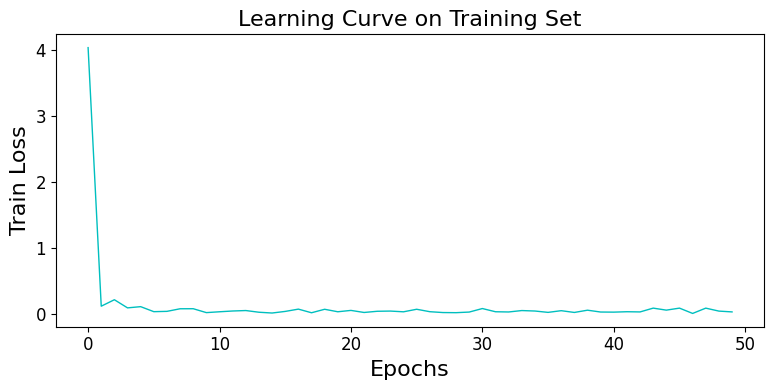

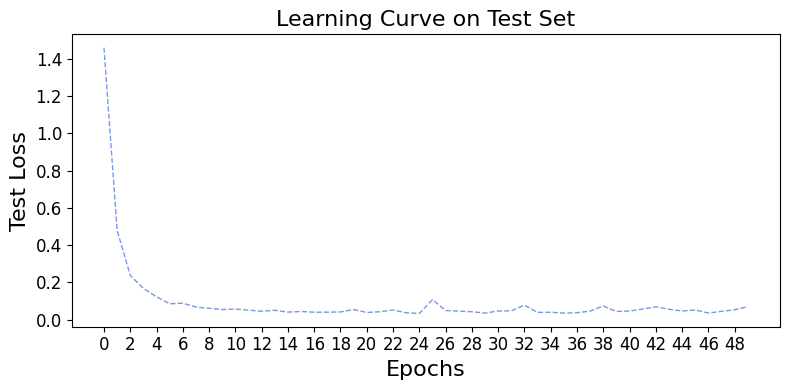

In [21]:
visLearningCurve(train_loss_log, test_loss_log)

### 1.4 Saving Model Weights and Using TensorBoard
During the training process, it’s often useful to save the model weights so that you can load the trained model later without retraining. PyTorch provides the **torch.save()** function to save model weights and **torch.load()** to load them. Additionally, TensorBoard is a powerful visualization tool that helps track and visualize metrics like loss and accuracy over time.

While this tutorial does not include the implementation of these features, you can explore the following [resources](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial2/Introduction_to_PyTorch.html) to learn how to. These features can be extremely helpful for monitoring training progress and managing model checkpoints.

## Section 2: GurobiPy - Mathematical Optimization Library

GurobiPy is the Python interface for the Gurobi Optimizer, a powerful tool for solving mathematical optimization problems.

**Common Applications of GurobiPy**:
- Linear Programming (LP)
- Integer Programming (IP)
- Mixed-Integer Programming (MIP)
- Quadratic Programming (QP)

**Objective**: In this section, we’ll cover the basics of setting up an optimization problem in GurobiPy and solve a simple production planning problem.


In [22]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 53.0 MB/s eta 0:00:00


In [23]:
import gurobipy as gp
from gurobipy import GRB

### Defining a Simple Optimization Problem

Let's create a production planning problem where we aim to maximize profit while meeting resource constraints. In this example:

- We have two products, A and B.
- Each product requires a certain amount of resources.
- We aim to determine the quantities of products A and B to produce to maximize profit while staying within resource limits.

**Problem Data**:
- Profit per unit of Product A: 20
- Profit per unit of Product B: 30
- Resource constraints:
  - Product A requires 1 unit of resource X and 2 units of resource Y.
  - Product B requires 1 unit of resource X and 1 unit of resource Y.
  - Total available units of resource X: 40
  - Total available units of resource Y: 50


In [24]:
# Define the model
model = gp.Model("production_planning")

# Define decision variables
x = model.addVar(vtype=GRB.CONTINUOUS, name="Product_A")  # Quantity of Product A
y = model.addVar(vtype=GRB.CONTINUOUS, name="Product_B")  # Quantity of Product B

# Set the objective: maximize profit
model.setObjective(20 * x + 30 * y, GRB.MAXIMIZE)

# Add resource constraints
model.addConstr(x + y <= 40, "Resource_X")  # Resource X constraint
model.addConstr(2 * x + y <= 50, "Resource_Y")  # Resource Y constraint

# Optimize the model
model.optimize()

# Print the results
if model.status == GRB.OPTIMAL:
    print(f"Optimal Production of Product A: {x.x}")
    print(f"Optimal Production of Product B: {y.x}")
    print(f"Maximum Profit: {model.objVal}")


Restricted license - for non-production use only - expires 2026-11-23
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 2 rows, 2 columns and 4 nonzeros
Model fingerprint: 0x8d2f47be
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [2e+01, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+01, 5e+01]
Presolve time: 0.01s
Presolved: 2 rows, 2 columns, 4 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.0000000e+31   3.500000e+30   5.000000e+01      0s
       1    1.2000000e+03   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.200000000e+03
Optimal Production of Product A: 0.0
Optimal Production of Product B: 40.0
Maximum Profit: 1200.0


For more complex problems, refer to the [Gurobi Documentation](https://www.gurobi.com/documentation/).

## Section 3: PyEPO PyTorch-based End-to-End Predict-then-Optimize Tool

*This notebook is based on three introductory notebook for [PyEPO](https://github.com/khalil-research/PyEPO?tab=readme-ov-file)*

PyEPO is an implementation that aims to support an end-to-end predict-then-optimize with linear objective function and unknown cost coefficients. The core component is the differentiable optimization solver, which is involved in updating the gradient of the cost coefficients with respect to the optimal solution.

We introduce how to build train a model based on [Smart Predict-then-Optimize ](https://arxiv.org/abs/1710.08005) using PyEPO.

In [25]:
!pip install pyepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.7 MB/s eta 0:00:00


### 3.1 Problem Example: Shortest Path

Consider a 5x5 grid network, represented as a weighted graph. The figure shows that each node has top, bottom, left, and right neighbors. We aim to find the shortest path from left top to right bottom.

<img src="https://github.com/khalil-research/PyEPO/blob/main/images/shortestpath.png?raw=1" width="500">

This 5 x 5 grid includes 40 arcs and therefore the cost vector $c$ would be a 40 dimensional vector. Let us generate random cost for each arc.

In [26]:
import random
# random seed
random.seed(42)
# set random cost for test
cost = [random.random() for _ in range(40)]

### 3.2 Introducation to optModel

``optModel`` is a module of PyEPO library. It is not a solver but serves as a container of a solver or an algorithm. This design allows for flexibility in the selection of solvers and algorithms by users. ``optModel`` treats these solvers as black boxes and provides interfaces ``_getModel``, ``setObj``, and ``solve``. Other modules of PyEPO can use ``optModel`` for tasks such as training and testing.

Methods of ``optModel``:
- ``_getModel``: Build and return optimization solver and corresponding decision variables.
- ``setObj``: Give a cost vector to set the objective function.
- ``solve``: Solve optimization problem and return optimal solution and objective value.

We can build models using optimzation solver `gurobi`

In [27]:
import gurobipy as gp
from gurobipy import GRB
from pyepo.model.grb import optGrbModel

class myShortestPathModel2(optGrbModel):

    def __init__(self, grid):
        """
        Args:
            grid (tuple of int): size of grid network
        """
        self.grid = grid
        self.arcs = self._getArcs()
        super().__init__()

    def _getModel(self):
        """
        A method to build Gurobi model

        Returns:
            tuple: optimization model and variables
        """
        # ceate a model
        m = gp.Model("shortest path")
        # varibles
        x = m.addVars(self.arcs, name="x")
        # sense
        m.modelSense = GRB.MINIMIZE
        # constraints
        for i in range(self.grid[0]):
            for j in range(self.grid[1]):
                v = i * self.grid[1] + j
                expr = 0
                for e in self.arcs:
                    # flow in
                    if v == e[1]:
                        expr += x[e]
                    # flow out
                    elif v == e[0]:
                        expr -= x[e]
                # source
                if i == 0 and j == 0:
                    m.addConstr(expr == -1)
                # sink
                elif i == self.grid[0] - 1 and j == self.grid[0] - 1:
                    m.addConstr(expr == 1)
                # transition
                else:
                    m.addConstr(expr == 0)
        return m, x


    def _getArcs(self):
        """
        A helper method to get list of arcs for grid network

        Returns:
            list: arcs
        """
        arcs = []
        for i in range(self.grid[0]):
            # edges on rows
            for j in range(self.grid[1] - 1):
                v = i * self.grid[1] + j
                arcs.append((v, v + 1))
            # edges in columns
            if i == self.grid[0] - 1:
                continue
            for j in range(self.grid[1]):
                v = i * self.grid[1] + j
                arcs.append((v, v + self.grid[1]))
        return arcs

Auto-Sklearn cannot be imported.


In [28]:
# Define Optimization Model
optmodel = myShortestPathModel2(grid=(5,5)) # init model
optmodel.setObj(cost) # set objective function
sol, obj = optmodel.solve() # solve
# print res
print('Obj: {}'.format(obj))
for i, e in enumerate(optmodel.arcs):
    if sol[i] > 1e-3:
        print(e)

Obj: 2.2869938328922332
(0, 1)
(1, 2)
(2, 3)
(3, 8)
(8, 9)
(9, 14)
(14, 19)
(19, 24)


### 3.3 Data Generation

The synthetic datasets include features x and cost coefficients
c. The feature vector $x_i \in \mathbb{R}^p$ follows a standard multivariate Gaussian distribution $\mathcal{N}(0,\mathbf{I})$, and the corresponding cost $c_i \in \mathbb{R}^d$ comes from a polynomial function f(x_i) multiplicated with a random noise.

In general, there are several parameters that users can control:

- num_data (n): data size
- num_features (p): feature dimension of costs
- deg (deg): polynomial degree of function
- noise_width (\hat{ϵ}): noise half-width of
seed: random state seed to generate data

Since, we have optimization model to solve in our hand, we know need some data to train our model. We generate synthetic dataset using the following equation:

$c_i^j = [\frac{1}{{3.5}^{deg}} (\frac{1}{\sqrt{p}}(\mathcal{B} \mathbf{x}_i)_j + 3)^{deg} + 1] \cdot \epsilon_i^j$,

where $\mathcal{B}$ is a random matrix, $i$ is the index of $i$-th sample and $j$ is the index of $j$-th element of the vector $c_i$.

PyEPO already contains util functions that generate data by following the above equation

In [29]:
import pyepo

grid = (5,5) # grid size
n = 1000 # number of data
p = 5 # feature dimention
deg = 4 # polynomial degree
e = 0.5 # noise half-width

# generate data for grid network (features and costs)
feats, costs = pyepo.data.shortestpath.genData(num_data=n+1000, num_features=p, grid=grid,
                                               deg=deg, noise_width=e, seed=42)

In [30]:
# features
print("Features:")
print(feats[0])
# costs
print("Costs:")
print(costs[0])

Features:
[-0.68002472  0.2322537   0.29307247 -0.71435142  1.86577451]
Costs:
[0.35391761 1.07858994 1.01396442 0.66493631 0.29919599 0.19120229
 0.92962621 0.24648609 0.33950669 0.19379419 0.78927149 0.52358102
 0.66013164 1.0846318  0.73023344 0.53221019 0.34958448 0.33129203
 1.4367641  0.72844442 1.39402493 0.89432676 1.03169003 0.46667478
 0.60684515 1.7148205  1.62555298 2.13901473 0.375338   0.51937908
 1.30751427 2.39109315 0.51398154 1.02980917 0.73931099 0.23779171
 0.35521389 0.25666491 0.70956306 1.69988172]


In [31]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, c_train, c_test = train_test_split(feats, costs, test_size=1000, random_state=42)

### 3.4 OptDataset

``optDataset`` is PyTorch Dataset, which stores the features and their corresponding costs of the objective function, and **solves optimization problems to get optimal solutions and optimal objective values**.

This object is very much similar to PyTorch Dataset. We can also use PyTorch DataLoader to wrap this dataset for the training purpose.

While it shares lots of similarity, ``optDataset`` accepts features features $\mathbf{x}$ and cost coefficients $\mathbf{c}$, then ultilizes ``optModel`` to find optimal solutions $\mathbf{w}^*$ and objective values $\mathbf{z}^*$.

In [32]:
# get optDataset
dataset_train = pyepo.data.dataset.optDataset(optmodel, x_train, c_train)
dataset_test = pyepo.data.dataset.optDataset(optmodel, x_test, c_test)

Optimizing for optDataset...


100%|██████████| 1000/1000 [00:00<00:00, 1245.54it/s]


Optimizing for optDataset...


100%|██████████| 1000/1000 [00:00<00:00, 1317.67it/s]


The ``optDataset`` contains 4 attributes: **features**, **costs**, (optimal) **solutions**, and (optimal) **objective values**. Saving the optimal solutions and values with the true cost vector reduces training time with SPO+ loss function since optimal solutions and objective values with the true cost vector is required to calculate the SPO+ loss.

In [33]:
# features
dataset_train.feats[:5]

array([[ 0.68356932, -1.36595571,  1.21194399,  0.26125053, -0.36927714],
       [-2.8321556 , -0.45115886,  0.5517408 ,  1.20026175, -0.46316136],
       [-0.85238677,  0.47536561,  0.63245422, -0.47417818, -0.77177196],
       [ 0.72894119, -0.69235077, -0.65903927, -0.57410068,  0.5364139 ],
       [-1.23252331,  0.55229994,  0.62563093, -0.69677182,  0.58202657]])

In [34]:
# costs
dataset_train.costs[:5]

array([[0.66423204, 1.31570609, 0.39314494, 1.56369511, 0.75385019,
        1.31562851, 0.64220475, 0.93906923, 0.91311846, 2.04161427,
        0.74907072, 0.5318552 , 0.68541336, 1.23490138, 0.93002909,
        0.44799287, 0.25995308, 0.34913271, 0.41296698, 0.31735299,
        0.21611971, 0.86564175, 0.8231998 , 0.21084682, 0.34851563,
        0.5123044 , 0.64182268, 0.39734889, 0.5353895 , 0.58975985,
        0.82311134, 0.22680251, 0.78549927, 0.87061416, 1.1983596 ,
        0.2857453 , 1.45720774, 0.99978659, 0.30051617, 0.29062359],
       [1.36202037, 1.60539413, 0.43680829, 0.43538718, 0.09457201,
        0.20794562, 0.15560289, 0.10297456, 1.32280424, 0.17186773,
        0.16530315, 0.06899043, 1.08747827, 0.03893738, 0.1008939 ,
        0.02468207, 0.05977335, 1.20703588, 0.90134767, 0.26220181,
        0.6374565 , 0.6714728 , 0.8947684 , 0.11022986, 0.02432527,
        0.50323957, 0.54521407, 0.61761709, 0.08326333, 0.45347036,
        0.04713232, 0.28148922, 0.68087899, 0.0

In [35]:
# solutions
dataset_train.sols[:5]

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0.,
        0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 1., 1.],
       [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 1., 1.]])

In [36]:
# objective values
dataset_train.objs[:5]

array([[4.52934109],
       [1.45274853],
       [2.33050111],
       [2.11744969],
       [2.72324556]])

In [37]:
# Define DataLoader
from torch.utils.data import DataLoader
batch_size = 32
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [38]:
for x, c, w, z in loader_train:
    # shape of features batch
    print(x.shape)
    # shape of true costs batch
    print(c.shape)
    # shape of true optimal solutions batch
    print(w.shape)
    # shape of true optimal objective values batch
    print(z.shape)
    break

torch.Size([32, 5])
torch.Size([32, 40])
torch.Size([32, 40])
torch.Size([32, 1])


### 5 Training Model with SPO+ Loss Function

In [39]:
from torch import nn

# build linear model
class LinearRegression(nn.Module):

    def __init__(self, num_feat, num_item):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(num_feat, num_item)

    def forward(self, x):
        out = self.linear(x)
        return out

In [40]:
import torch

num_feat = 5
num_item = 40 # We have 40 arcs to predict

# init model
reg = LinearRegression(num_feat,num_item)

#### Smart Predict-then-Optimize Framework


Smart Predict-then-Optimize Framework is a framework that is designed to train the prediction model to minimize the decision error induced by the prediction. They introduces SPO/SPO+ loss function to measure the decision error induced by the prediction $\hat{c}$

\begin{equation}
\begin{aligned}
    &\ell_{\mathrm{SPO}} = c^\top w^*(\hat{c}) - c^\top w^*(c) \\
    &\ell_{\mathrm{SPO+}} = \underset{w \in S}{\max} \{
c^\top w -2\hat{c}^\top w \} + 2\hat{c}^\top w^*(\hat{c}) - z^*(c)
\end{aligned}
\end{equation}
where $w^*(c)$ denotes the optimal solution with cost vector $c$ and z^*(c) denotes the optimal objective value with the cost vector $c$. Due to the its structure, calculating the SPO/SPO+ loss requires solving an optimization problem with cost vector $c$ and $\hat{c}$.


We will be using SPO+ loss function to train our model.

The main test performance metric should be normalized test regret which is induced by SPO loss function.

``pyepo.metric.regret`` is to evaluate model performance. Regret (also called SPO loss) $l_{Regret}(\hat{\mathbf{c}}, \mathbf{c}) = \mathbf{c}^T \mathbf{w}^*(\hat{c}) - z^*(c)$ aims to measure the error in decision-making. It evaluates the distance between the objective value of the solution from predicted cost $\hat{\mathbf{c}}$ and the true optimal objective value $z^*(c)$. After it is normalized by the sum of absolute sum of objective values which is $\sum_i |z^*(c_i)|$.

To calculate regret, ``pyepo.metric.regret`` requires:
- ``predmodel``: a regression neural network for cost prediction
- ``optmodel``: an PyEPO optimization model
- ``dataloader``: PyTorch dataloader from optDataset to evaluate

The following code block is an example:

In [41]:
import pyepo
regret = pyepo.metric.regret(reg, optmodel, loader_test)
regret

0.6664645629530142

In [42]:
import time

# train model
def trainModel(model, loss_func, method_name, num_epochs=20, lr=1e-2):
    # set adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if torch.cuda.is_available():
      model = model.cuda()
    # train mode
    model.train()
    # init log
    train_loss_log = []
    loss_log_regret = [pyepo.metric.regret(model, optmodel, loader_test)]
    # init elpased time
    elapsed = 0
    for epoch in range(num_epochs):
        # start timing
        tick = time.time()
        # load data
        train_loss = 0
        for i, data in enumerate(loader_train):
            x, c, w, z = data
            # cuda
            if torch.cuda.is_available():
                x, c, w, z = x.cuda(), c.cuda(), w.cuda(), z.cuda()
            # forward pass
            cp = model(x)
            if method_name == "spo+":
                loss = loss_func(cp, c, w, z)
            elif method_name == "mse":
                loss = loss_func(cp, c)
            else:
                raise ValueError("Method name {} not supported".format(method_name))
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # record time
            tock = time.time()
            elapsed += tock - tick
            train_loss += loss.item()
        train_loss /= len(loader_train)
        train_loss_log.append(train_loss)
        regret = pyepo.metric.regret(model, optmodel, loader_test)
        loss_log_regret.append(regret)
        print("Epoch {:2},  Loss: {:9.4f},  Regret: {:7.4f}%".format(epoch+1, train_loss, regret*100))
    print("Total Elapsed Time: {:.2f} Sec.".format(elapsed))
    return train_loss_log, loss_log_regret

In [43]:
from matplotlib import pyplot as plt

def visLearningCurve(loss_log, loss_log_regret):
    # create figure and subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))

    # draw plot for training loss
    ax1.plot(loss_log, color="c", lw=1)
    ax1.tick_params(axis="both", which="major", labelsize=12)
    ax1.set_xlabel("Epochs", fontsize=16)
    ax1.set_ylabel("Loss", fontsize=16)
    ax1.set_title("Learning Curve on Training Set", fontsize=16)

    # draw plot for regret on test
    ax2.plot(loss_log_regret, color="royalblue", ls="--", alpha=0.7, lw=1)
    ax2.set_xticks(range(0, len(loss_log_regret), 2))
    ax2.tick_params(axis="both", which="major", labelsize=12)
    ax2.set_ylim(0, 0.5)
    ax2.set_xlabel("Epochs", fontsize=16)
    ax2.set_ylabel("Normalized Regret", fontsize=16)
    ax2.set_title("Learning Curve on Test Set", fontsize=16)

    plt.show()

``pyepo.func.SPOPlus`` allows us to set a SPO+ loss for training, which requires parameters:
- ``optmodel``: an PyEPO optimization model
- ``processes``: number of processors for multi-thread, 1 for single-core, 0 for all of cores

In [44]:
# init SPO+ loss
spop = pyepo.func.SPOPlus(optmodel, processes=1)

Num of cores: 1


In [45]:
epochs = 20
learning_rate = 1e-2
method_name = "spo+"
reg = LinearRegression(num_feat,num_item)

loss_log_lr_spo, loss_log_regret_lr_spo = trainModel(reg, loss_func=spop, method_name="spo+")

Epoch  1,  Loss:    4.1801,  Regret:  9.1443%
Epoch  2,  Loss:    1.4422,  Regret:  7.7459%
Epoch  3,  Loss:    1.2846,  Regret:  7.8221%
Epoch  4,  Loss:    1.2750,  Regret:  6.8285%
Epoch  5,  Loss:    1.2655,  Regret:  7.0678%
Epoch  6,  Loss:    1.2621,  Regret:  7.2889%
Epoch  7,  Loss:    1.2607,  Regret:  7.0184%
Epoch  8,  Loss:    1.2418,  Regret:  6.7895%
Epoch  9,  Loss:    1.2345,  Regret:  7.3787%
Epoch 10,  Loss:    1.2686,  Regret:  7.6922%
Epoch 11,  Loss:    1.2612,  Regret:  7.9890%
Epoch 12,  Loss:    1.2461,  Regret:  7.1665%
Epoch 13,  Loss:    1.2914,  Regret:  7.2575%
Epoch 14,  Loss:    1.2972,  Regret:  7.1873%
Epoch 15,  Loss:    1.2685,  Regret:  7.4069%
Epoch 16,  Loss:    1.2566,  Regret:  7.0319%
Epoch 17,  Loss:    1.2802,  Regret:  7.4532%
Epoch 18,  Loss:    1.2764,  Regret:  7.6849%
Epoch 19,  Loss:    1.2704,  Regret:  7.4476%
Epoch 20,  Loss:    1.2635,  Regret:  7.2019%
Total Elapsed Time: 414.59 Sec.


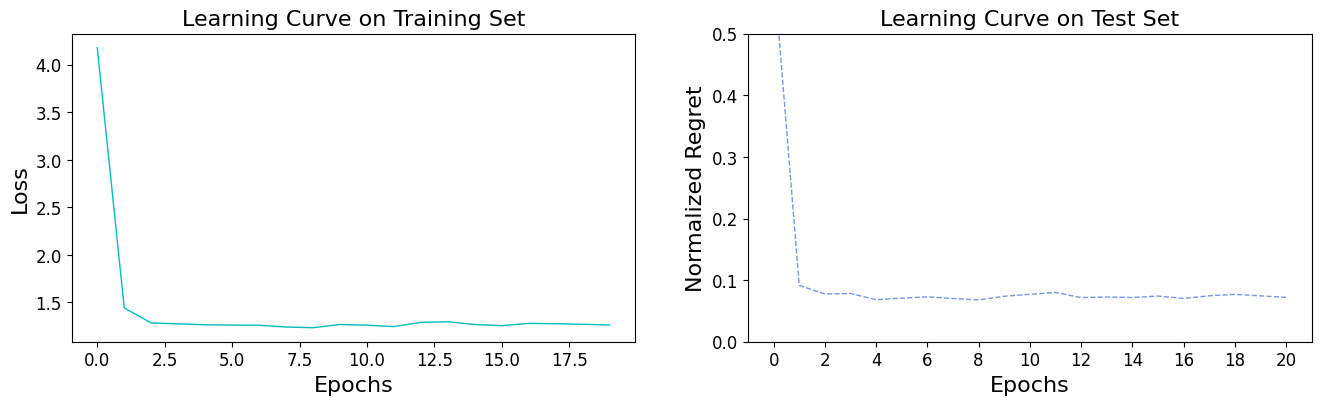

In [46]:
visLearningCurve(loss_log_lr_spo, loss_log_regret_lr_spo)

Now Let us train our model using MSELoss function which is generally used to minimize the prediction error of the model.

In [47]:
epochs = 20
learning_rate = 1e-2
method_name = "mse"
loss_func = nn.MSELoss()
reg = LinearRegression(num_feat,num_item)

loss_log_lr_mse, loss_log_regret_lr_mse = trainModel(reg, loss_func=loss_func, method_name=method_name)

Epoch  1,  Loss:    0.9414,  Regret: 48.3609%
Epoch  2,  Loss:    0.4004,  Regret: 18.3721%
Epoch  3,  Loss:    0.2269,  Regret: 10.2719%
Epoch  4,  Loss:    0.1706,  Regret:  8.4415%
Epoch  5,  Loss:    0.1552,  Regret:  7.9647%
Epoch  6,  Loss:    0.1492,  Regret:  8.2103%
Epoch  7,  Loss:    0.1497,  Regret:  8.4891%
Epoch  8,  Loss:    0.1497,  Regret:  8.2716%
Epoch  9,  Loss:    0.1495,  Regret:  8.4215%
Epoch 10,  Loss:    0.1495,  Regret:  8.6261%
Epoch 11,  Loss:    0.1490,  Regret:  8.4254%
Epoch 12,  Loss:    0.1502,  Regret:  8.4360%
Epoch 13,  Loss:    0.1496,  Regret:  8.6040%
Epoch 14,  Loss:    0.1493,  Regret:  8.2673%
Epoch 15,  Loss:    0.1505,  Regret:  8.3913%
Epoch 16,  Loss:    0.1491,  Regret:  8.5303%
Epoch 17,  Loss:    0.1490,  Regret:  8.3173%
Epoch 18,  Loss:    0.1683,  Regret:  8.4222%
Epoch 19,  Loss:    0.1524,  Regret:  8.5967%
Epoch 20,  Loss:    0.1504,  Regret:  8.7029%
Total Elapsed Time: 40.26 Sec.


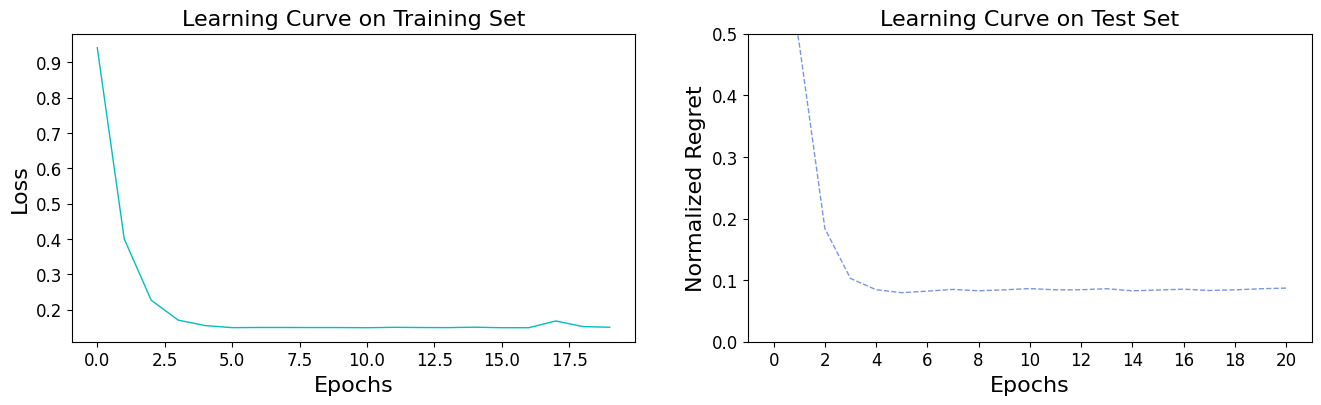

In [48]:
visLearningCurve(loss_log_lr_mse, loss_log_regret_lr_mse)

Instead of training simple linear regression model, we can also train NN models that we learned through the course.

In [49]:
# build single hidden layer NN

import torch.nn.functional as F

class MLP(nn.Module):

    def __init__(self, num_feat, num_item, num_hidden):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(num_feat, num_hidden)
        self.fc2 = nn.Linear(num_hidden, num_item)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        out = self.fc2(x)
        return out

In [50]:
epochs = 20
learning_rate = 2e-3
method_name = "spo+"
hidden_dim = 20
mlp = MLP(num_feat,num_item,hidden_dim)

loss_log_mlp_spo, loss_log_regret_mlp_spo = trainModel(mlp, loss_func=spop, method_name=method_name)

Epoch  1,  Loss:    2.8909,  Regret: 10.5056%
Epoch  2,  Loss:    1.3945,  Regret:  7.9793%
Epoch  3,  Loss:    1.2686,  Regret:  7.6752%
Epoch  4,  Loss:    1.2317,  Regret:  8.0162%
Epoch  5,  Loss:    1.2300,  Regret:  7.6393%
Epoch  6,  Loss:    1.1756,  Regret:  8.2123%
Epoch  7,  Loss:    1.1757,  Regret:  8.4509%
Epoch  8,  Loss:    1.1281,  Regret:  8.6500%
Epoch  9,  Loss:    1.1111,  Regret:  7.8607%
Epoch 10,  Loss:    1.1514,  Regret:  7.6909%
Epoch 11,  Loss:    1.0961,  Regret:  7.6051%
Epoch 12,  Loss:    1.0762,  Regret:  7.6264%
Epoch 13,  Loss:    1.1367,  Regret:  8.2505%
Epoch 14,  Loss:    1.1022,  Regret:  7.4416%
Epoch 15,  Loss:    1.1289,  Regret:  7.7085%
Epoch 16,  Loss:    1.0604,  Regret:  7.6788%
Epoch 17,  Loss:    1.0712,  Regret:  7.5225%
Epoch 18,  Loss:    1.1157,  Regret:  8.2169%
Epoch 19,  Loss:    1.1096,  Regret:  7.4446%
Epoch 20,  Loss:    1.0883,  Regret:  7.6276%
Total Elapsed Time: 436.75 Sec.


In [51]:
epochs = 20
learning_rate = 2e-3
loss_func = nn.MSELoss()
method_name = "mse"
hidden_dim = 20
mlp = MLP(num_feat,num_item,hidden_dim)

loss_log_mlp_mse, loss_log_regret_mlp_mse = trainModel(mlp, loss_func=loss_func, method_name=method_name)

Epoch  1,  Loss:    0.4120,  Regret: 17.8462%
Epoch  2,  Loss:    0.1338,  Regret:  9.9723%
Epoch  3,  Loss:    0.1074,  Regret:  8.7037%
Epoch  4,  Loss:    0.1038,  Regret:  8.2573%
Epoch  5,  Loss:    0.0986,  Regret:  7.9434%
Epoch  6,  Loss:    0.0998,  Regret:  8.1756%
Epoch  7,  Loss:    0.0953,  Regret:  8.4569%
Epoch  8,  Loss:    0.0933,  Regret:  8.2207%
Epoch  9,  Loss:    0.0919,  Regret:  7.8258%
Epoch 10,  Loss:    0.0903,  Regret:  7.9133%
Epoch 11,  Loss:    0.0887,  Regret:  7.6994%
Epoch 12,  Loss:    0.0882,  Regret:  7.6900%
Epoch 13,  Loss:    0.0881,  Regret:  8.2507%
Epoch 14,  Loss:    0.0905,  Regret:  7.9859%
Epoch 15,  Loss:    0.0890,  Regret:  8.1542%
Epoch 16,  Loss:    0.0867,  Regret:  7.8426%
Epoch 17,  Loss:    0.0858,  Regret:  7.7095%
Epoch 18,  Loss:    0.0864,  Regret:  7.8112%
Epoch 19,  Loss:    0.0858,  Regret:  7.8545%
Epoch 20,  Loss:    0.0852,  Regret:  7.7061%
Total Elapsed Time: 29.76 Sec.


In [52]:
# Find the lowest regret among the model and make a pandas table for that
df = {
    "Model": ["SPO+ Linear Regression", "MSE Linear Regression", "SPO+ MLP", "MSE MLP"],
    "Min Regret": [min(loss_log_regret_lr_spo), min(loss_log_regret_lr_mse), min(loss_log_regret_mlp_spo), min(loss_log_regret_mlp_mse)]
}

import pandas as pd

df = pd.DataFrame(df)
df["Min Regret"] = (df["Min Regret"] * 100).round(2)
df

,Model,Min Regret
0,SPO+ Linear Regression,6.79
1,MSE Linear Regression,7.96
2,SPO+ MLP,7.44
3,MSE MLP,7.69
